In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')


In [23]:
import joblib

scaler = joblib.load('../weights/scaler.pkl')

train_scaled = pd.read_csv('../dataset/processed/train_scaled.csv')
test_scaled  = pd.read_csv('../dataset/processed/test_scaled.csv')

selected_features = ['distance', 'quote_signal', 'weight', 'market_index', 'equip_Dry Van', 'equip_Flatbed', 'equip_Reefer']

X_train_scaled = train_scaled[selected_features].values
y_train        = train_scaled['posted_rate']

X_test_scaled  = test_scaled[selected_features].values
y_test         = test_scaled['posted_rate']

print("Train:", X_train_scaled.shape)
print("Test: ", X_test_scaled.shape)

Train: (38009, 7)
Test:  (9399, 7)


In [24]:
X_train_scaled[:5], y_train[:5]

(array([[-1.18636085,  1.24711724, -0.09025021, -1.02942275,  0.87276282,
         -0.47058197, -0.5790009 ],
        [-1.17782355,  1.38640369, -1.73248807, -0.90886176, -1.14578666,
         -0.47058197,  1.72711303],
        [-0.23142238, -0.7941701 ,  0.04297873, -0.70069351,  0.87276282,
         -0.47058197, -0.5790009 ],
        [-0.23472714, -0.67485051,  0.11968251, -1.10192101,  0.87276282,
         -0.47058197, -0.5790009 ],
        [-0.81787991,  1.86594174,  0.47688146, -0.85557616, -1.14578666,
         -0.47058197,  1.72711303]]),
 0     645.41
 1     679.97
 2    1802.54
 3    1827.28
 4    1380.28
 Name: posted_rate, dtype: float64)

In [25]:
models = {
    'Linear Regression'   : LinearRegression(),
    'Ridge'               : Ridge(alpha=1.0),
    'Lasso'               : Lasso(alpha=1.0),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=100, random_state=42),
}

results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    
    results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    print(f"{name:25s} | MAE: {mae:.2f} | RMSE: {rmse:.2f} | R2: {r2:.4f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False)
print("\n--- Best Model ---")
print(results_df.iloc[0])

Linear Regression         | MAE: 151.96 | RMSE: 281.21 | R2: 0.9583
Ridge                     | MAE: 151.96 | RMSE: 281.21 | R2: 0.9583
Lasso                     | MAE: 150.92 | RMSE: 280.78 | R2: 0.9584
Random Forest             | MAE: 102.48 | RMSE: 263.10 | R2: 0.9635
Gradient Boosting         | MAE: 120.15 | RMSE: 266.22 | R2: 0.9626

--- Best Model ---
Model    Random Forest
MAE         102.478934
RMSE        263.101536
R2            0.963481
Name: 3, dtype: object


In [27]:
print("Mean posted_rate :", y_test.mean().round(2))
print("Std posted_rate  :", y_test.std().round(2))
print("MAE as % of mean :", (160.59 / y_test.mean() * 100).round(2), "%")

Mean posted_rate : 2354.4
Std posted_rate  : 1376.86
MAE as % of mean : 6.82 %


# Hyper parameter tuning for Random forest

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Random Forest
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

# Hyperparameter search space
param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30, 40],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", 0.7, 1.0]
}

# Randomized search
rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=30,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Train
rf_search.fit(X_train_scaled, y_train)

# Best model
best_rf = rf_search.best_estimator_

print("Best Parameters:")
print(rf_search.best_params_)

# Test prediction
preds = best_rf.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("\n--- Tuned Random Forest ---")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 0.7, 'max_depth': None}

--- Tuned Random Forest ---
MAE  : 97.06
RMSE : 253.97
R²   : 0.9660


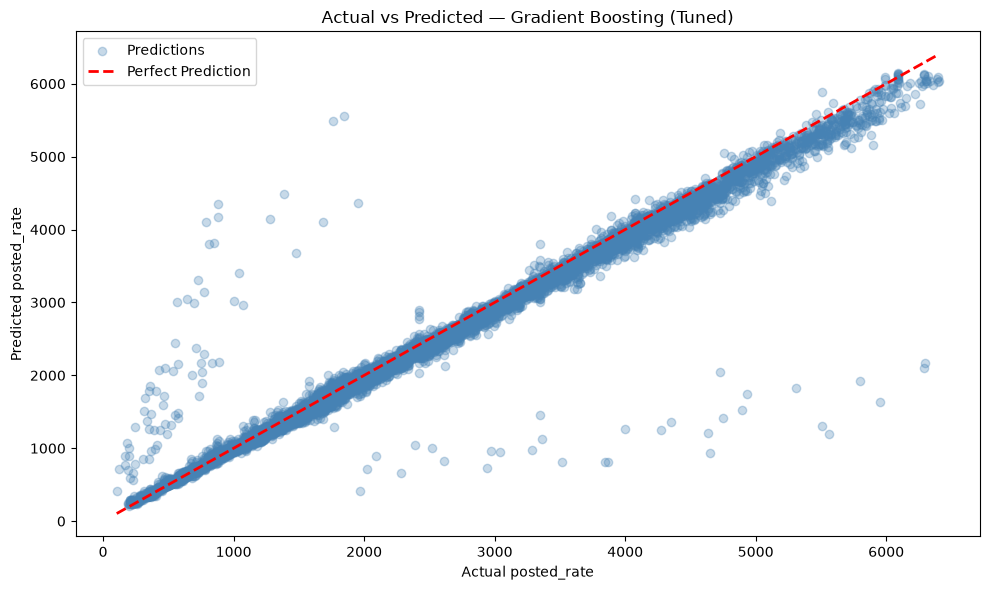

In [13]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, preds, alpha=0.3, color='steelblue', label='Predictions')
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual posted_rate')
plt.ylabel('Predicted posted_rate')
plt.title('Actual vs Predicted — Gradient Boosting (Tuned)')
plt.legend()
plt.tight_layout()
plt.show()

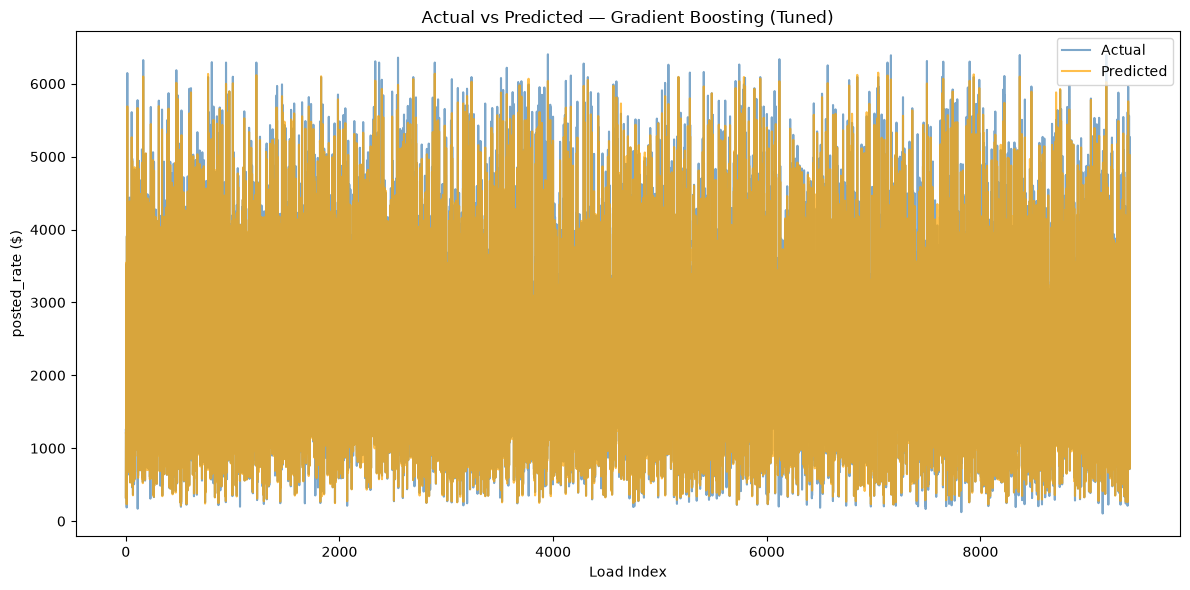

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test)), y_test.values,  color='steelblue', label='Actual',    alpha=0.7)
plt.plot(range(len(y_test)), preds,           color='orange',    label='Predicted', alpha=0.7)
plt.xlabel('Load Index')
plt.ylabel('posted_rate ($)')
plt.title('Actual vs Predicted — Gradient Boosting (Tuned)')
plt.legend()
plt.tight_layout()
plt.show()

                   Model         MAE        RMSE        R2
5  Random Forest (Tuned)   97.064471  253.970856  0.965972
0          Random Forest  102.478934  263.101536  0.963481
1      Gradient Boosting  120.150419  266.222956  0.962610
2                  Lasso  150.916743  280.776980  0.958410
3                  Ridge  151.956545  281.214121  0.958280
4      Linear Regression  151.959134  281.214246  0.958280


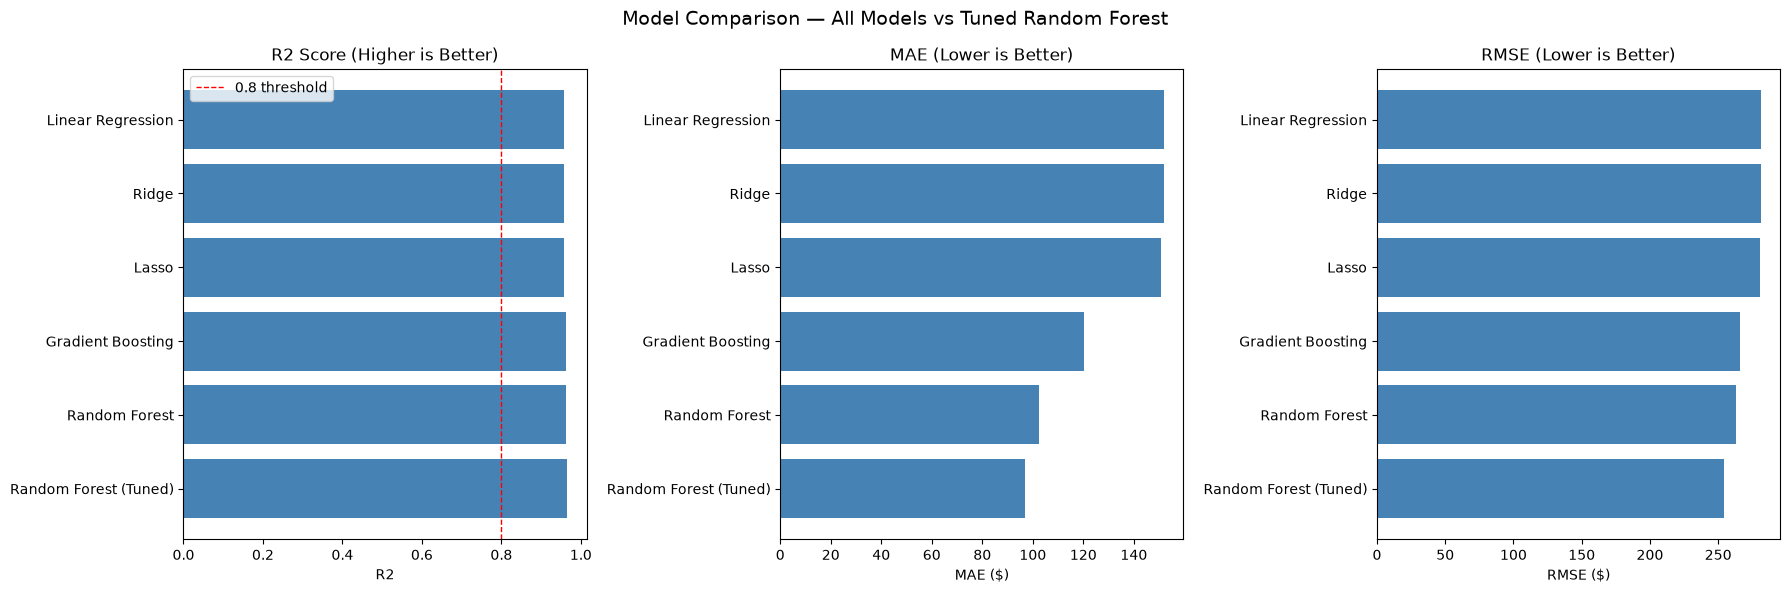

In [15]:
# Add tuned RF to results
tuned_results = {
    'Model': 'Random Forest (Tuned)',
    'MAE'  : mae,
    'RMSE' : rmse,
    'R2'   : r2
}

comparison_df = pd.concat([
    results_df, 
    pd.DataFrame([tuned_results])
], ignore_index=True).sort_values('R2', ascending=False)

print(comparison_df)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['steelblue' if m != 'Gradient Boosting (Tuned)' else 'seagreen' 
          for m in comparison_df['Model']]

# R2
axes[0].barh(comparison_df['Model'], comparison_df['R2'], color=colors)
axes[0].set_title('R2 Score (Higher is Better)')
axes[0].set_xlabel('R2')
axes[0].axvline(0.8, color='red', linestyle='--', linewidth=1, label='0.8 threshold')
axes[0].legend()

# MAE
axes[1].barh(comparison_df['Model'], comparison_df['MAE'], color=colors)
axes[1].set_title('MAE (Lower is Better)')
axes[1].set_xlabel('MAE ($)')

# RMSE
axes[2].barh(comparison_df['Model'], comparison_df['RMSE'], color=colors)
axes[2].set_title('RMSE (Lower is Better)')
axes[2].set_xlabel('RMSE ($)')

plt.suptitle('Model Comparison — All Models vs Tuned Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
joblib.dump(best_rf, '../weights/best_model_rf_tuned.pkl')
print("Saved best_model_rf_tuned.pkl")


Saved best_model_rf_tuned.pkl
